In [3]:
# STEP 1: Basic Tire Degradation Simulation

# Total race laps
total_laps = 60

# Soft tire parameters
base_time = 90        # base lap time in seconds
degradation = 0.25    # lap time increase per lap

# Store total race time
total_race_time = 0

print("Lap Times:\n")

for lap in range(1, total_laps + 1):
    lap_time = base_time + degradation * lap
    total_race_time += lap_time
    print("Lap", lap, ":", round(lap_time, 2), "seconds")

print("\nTotal Race Time:", round(total_race_time, 2), "seconds")


Lap Times:

Lap 1 : 90.25 seconds
Lap 2 : 90.5 seconds
Lap 3 : 90.75 seconds
Lap 4 : 91.0 seconds
Lap 5 : 91.25 seconds
Lap 6 : 91.5 seconds
Lap 7 : 91.75 seconds
Lap 8 : 92.0 seconds
Lap 9 : 92.25 seconds
Lap 10 : 92.5 seconds
Lap 11 : 92.75 seconds
Lap 12 : 93.0 seconds
Lap 13 : 93.25 seconds
Lap 14 : 93.5 seconds
Lap 15 : 93.75 seconds
Lap 16 : 94.0 seconds
Lap 17 : 94.25 seconds
Lap 18 : 94.5 seconds
Lap 19 : 94.75 seconds
Lap 20 : 95.0 seconds
Lap 21 : 95.25 seconds
Lap 22 : 95.5 seconds
Lap 23 : 95.75 seconds
Lap 24 : 96.0 seconds
Lap 25 : 96.25 seconds
Lap 26 : 96.5 seconds
Lap 27 : 96.75 seconds
Lap 28 : 97.0 seconds
Lap 29 : 97.25 seconds
Lap 30 : 97.5 seconds
Lap 31 : 97.75 seconds
Lap 32 : 98.0 seconds
Lap 33 : 98.25 seconds
Lap 34 : 98.5 seconds
Lap 35 : 98.75 seconds
Lap 36 : 99.0 seconds
Lap 37 : 99.25 seconds
Lap 38 : 99.5 seconds
Lap 39 : 99.75 seconds
Lap 40 : 100.0 seconds
Lap 41 : 100.25 seconds
Lap 42 : 100.5 seconds
Lap 43 : 100.75 seconds
Lap 44 : 101.0 seconds
La

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# STEP 2: Compare Tire Compounds

total_laps = 60

tires = {
    "Soft": {"base": 90, "deg": 0.25},
    "Medium": {"base": 91.5, "deg": 0.15},
    "Hard": {"base": 93, "deg": 0.08}
}

for tire_name, values in tires.items():
    total_time = 0

    for lap in range(1, total_laps + 1):
        lap_time = values["base"] + values["deg"] * lap
        total_time += lap_time

    print(tire_name, "Total Race Time:", round(total_time, 2))


Soft Total Race Time: 5857.5
Medium Total Race Time: 5764.5
Hard Total Race Time: 5726.4


In [6]:
# STEP 3: One Pit Stop Strategy Simulation

total_laps = 60
pit_lap = 17
pit_loss = 22  # seconds lost during pit stop

tires = {
    "Soft": {"base": 90, "deg": 0.25},
    "Medium": {"base": 91.5, "deg": 0.15},
    "Hard": {"base": 93, "deg": 0.08}
}

def simulate_strategy(first_tire, second_tire):
    total_time = 0

    for lap in range(1, total_laps + 1):

        if lap < pit_lap:
            lap_time = tires[first_tire]["base"] + tires[first_tire]["deg"] * lap

        elif lap == pit_lap:
            lap_time = tires[first_tire]["base"] + tires[first_tire]["deg"] * lap + pit_loss

        else:
            stint_lap = lap - pit_lap
            lap_time = tires[second_tire]["base"] + tires[second_tire]["deg"] * stint_lap

        total_time += lap_time

    return total_time


# Compare strategies
strategies = [
    ("Soft", "Medium"),
    ("Medium", "Hard"),
    ("Hard", "Medium")
]

for s in strategies:
    time = simulate_strategy(s[0], s[1])
    print(f"{s[0]} -> {s[1]} Strategy:", round(time, 2))


Soft -> Medium Strategy: 5666.65
Medium -> Hard Strategy: 5675.13
Hard -> Medium Strategy: 5691.64


In [7]:
# STEP 4: Find Optimal Pit Lap (Soft -> Medium)

best_time = float("inf")
best_pit = None

for test_pit in range(10, 31):  # testing pit between lap 10 and 30
    pit_lap = test_pit
    total_time = 0

    for lap in range(1, total_laps + 1):

        if lap < pit_lap:
            lap_time = tires["Soft"]["base"] + tires["Soft"]["deg"] * lap

        elif lap == pit_lap:
            lap_time = tires["Soft"]["base"] + tires["Soft"]["deg"] * lap + pit_loss

        else:
            stint_lap = lap - pit_lap
            lap_time = tires["Medium"]["base"] + tires["Medium"]["deg"] * stint_lap

        total_time += lap_time

    if total_time < best_time:
        best_time = total_time
        best_pit = pit_lap

print("Best Pit Lap:", best_pit)
print("Best Race Time:", round(best_time, 2))


Best Pit Lap: 26
Best Race Time: 5650.0


In [8]:
import random

# Monte Carlo Simulation (Soft -> Medium)

simulations = 500
best_pit = 26  # from previous result

results = []

for sim in range(simulations):
    total_time = 0

    for lap in range(1, total_laps + 1):

        # random small lap variation (+/- 0.1s)
        noise = random.uniform(-0.1, 0.1)

        if lap < best_pit:
            lap_time = tires["Soft"]["base"] + tires["Soft"]["deg"] * lap

        elif lap == best_pit:
            lap_time = tires["Soft"]["base"] + tires["Soft"]["deg"] * lap + pit_loss

        else:
            stint_lap = lap - best_pit
            lap_time = tires["Medium"]["base"] + tires["Medium"]["deg"] * stint_lap

        total_time += lap_time + noise

    results.append(total_time)

print("Average Race Time:", round(sum(results)/len(results), 2))
print("Best Simulated Time:", round(min(results), 2))
print("Worst Simulated Time:", round(max(results), 2))


Average Race Time: 5650.05
Best Simulated Time: 5648.58
Worst Simulated Time: 5651.46


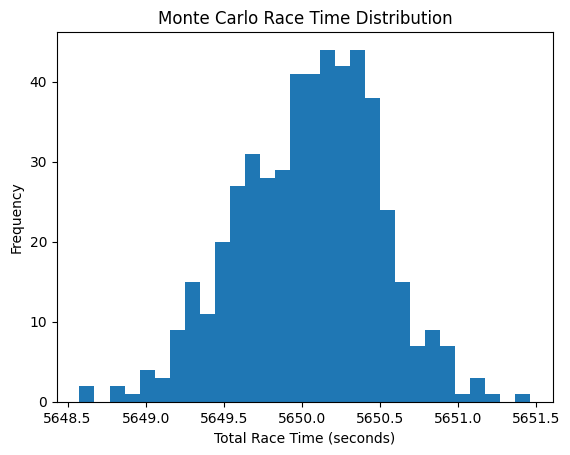

In [9]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(results, bins=30)
plt.xlabel("Total Race Time (seconds)")
plt.ylabel("Frequency")
plt.title("Monte Carlo Race Time Distribution")
plt.show()


In [10]:
import random
import numpy as np

simulations = 500
pit_loss = 22
total_laps = 60

strategies = [
    ("Soft", "Medium"),
    ("Soft", "Hard"),
    ("Medium", "Hard")
]

results_summary = {}

for strategy in strategies:

    best_pit = 26  # using previously optimized pit lap
    sim_results = []

    for sim in range(simulations):
        total_time = 0

        for lap in range(1, total_laps + 1):
            noise = random.uniform(-0.1, 0.1)

            if lap < best_pit:
                lap_time = tires[strategy[0]]["base"] + tires[strategy[0]]["deg"] * lap

            elif lap == best_pit:
                lap_time = tires[strategy[0]]["base"] + tires[strategy[0]]["deg"] * lap + pit_loss

            else:
                stint_lap = lap - best_pit
                lap_time = tires[strategy[1]]["base"] + tires[strategy[1]]["deg"] * stint_lap

            total_time += lap_time + noise

        sim_results.append(total_time)

    avg_time = np.mean(sim_results)
    std_dev = np.std(sim_results)

    results_summary[f"{strategy[0]} -> {strategy[1]}"] = (avg_time, std_dev)

# Print comparison
for strat, values in results_summary.items():
    print(strat)
    print("Average Time:", round(values[0], 2))
    print("Risk (Std Dev):", round(values[1], 3))
    print("-----")


Soft -> Medium
Average Time: 5649.98
Risk (Std Dev): 0.441
-----
Soft -> Hard
Average Time: 5659.36
Risk (Std Dev): 0.441
-----
Medium -> Hard
Average Time: 5663.26
Risk (Std Dev): 0.428
-----


In [11]:
import random
import numpy as np

total_laps = 60
pit_loss = 22
simulations = 300

tires = {
    "Soft": {"base": 90, "deg": 0.25},
    "Medium": {"base": 91.5, "deg": 0.15},
    "Hard": {"base": 93, "deg": 0.08}
}

strategies = [
    ("Soft", "Medium"),
    ("Soft", "Hard"),
    ("Medium", "Hard")
]

def simulate_with_features(first_tire, second_tire, pit_lap):
    total_time = 0
    safety_car_triggered = False

    # Random Safety Car probability (15%)
    if random.random() < 0.15:
        safety_car_lap = random.randint(5, 50)
        safety_car_triggered = True
    else:
        safety_car_lap = None

    for lap in range(1, total_laps + 1):

        # Tire selection
        if lap < pit_lap:
            base = tires[first_tire]["base"]
            deg = tires[first_tire]["deg"]
            stint_lap = lap
        elif lap == pit_lap:
            base = tires[first_tire]["base"]
            deg = tires[first_tire]["deg"]
            stint_lap = lap
            total_time += pit_loss
        else:
            base = tires[second_tire]["base"]
            deg = tires[second_tire]["deg"]
            stint_lap = lap - pit_lap

        lap_time = base + deg * stint_lap

        # Add traffic penalty (random 5% chance per lap)
        if random.random() < 0.05:
            lap_time += random.uniform(0.3, 1.0)

        # Safety Car reduces lap time artificially
        if safety_car_triggered and lap == safety_car_lap:
         lap_time *= 1.15   # 15% slower lap


        # Small performance noise
        lap_time += random.uniform(-0.1, 0.1)

        total_time += lap_time

    return total_time


results_summary = {}

for strategy in strategies:

    best_avg = float("inf")
    best_pit = None

    # Automatically test pit windows
    for test_pit in range(10, 31):

        sim_results = []

        for _ in range(simulations):
            race_time = simulate_with_features(strategy[0], strategy[1], test_pit)
            sim_results.append(race_time)

        avg_time = np.mean(sim_results)

        if avg_time < best_avg:
            best_avg = avg_time
            best_pit = test_pit

    results_summary[f"{strategy[0]} -> {strategy[1]}"] = (best_avg, best_pit)

for strat, values in results_summary.items():
    print(strat)
    print("Best Avg Time:", round(values[0], 2))
    print("Optimal Pit Lap:", values[1])
    print("-----")


Soft -> Medium
Best Avg Time: 5653.49
Optimal Pit Lap: 26
-----
Soft -> Hard
Best Avg Time: 5662.18
Optimal Pit Lap: 23
-----
Medium -> Hard
Best Avg Time: 5667.02
Optimal Pit Lap: 27
-----


In [12]:

pip install streamlit


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 65.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 87.3 MB/s eta 0:00:00
  Attempting uninstall: cachetools
    Found existing installation: cachetools 7.0.1
    Uninstalling cachetools-7.0.1:
      Successfully uninstalled cachetools-7.0.1


In [13]:
import streamlit as st
st.title("F1 Strategy Simulator")


2026-02-18 17:42:11.443 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-18 17:42:11.634 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-02-18 17:42:11.635 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-18 17:42:11.636 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [14]:
pip install fastf1


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.0/123.0 kB 6.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.6/69.6 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 68.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.7/70.7 kB 5.1 MB/s eta 0:00:00
  Created wheel for msgpack: filename=msgpack-1.0.2-cp312-cp312-linux_x86_64.whl size=15820 sha256=40e589a4d6166b0104e8fb28196715304fd4e4c19be57ac11cac26541c68e40d
  Stored in directory: /root/.cache/pip/wheels/67/a6/40/eda0983e595bbf3841af96dbff2340be72dfac96796fc3d578
Successfully built msgpack
  Attempting uninstall: msgpack
    Found existing installation: msgpack 1.1.2
    Uninstalling msgpack-1.1.2:
      Successfully uninstalled msgpack-1.1.2


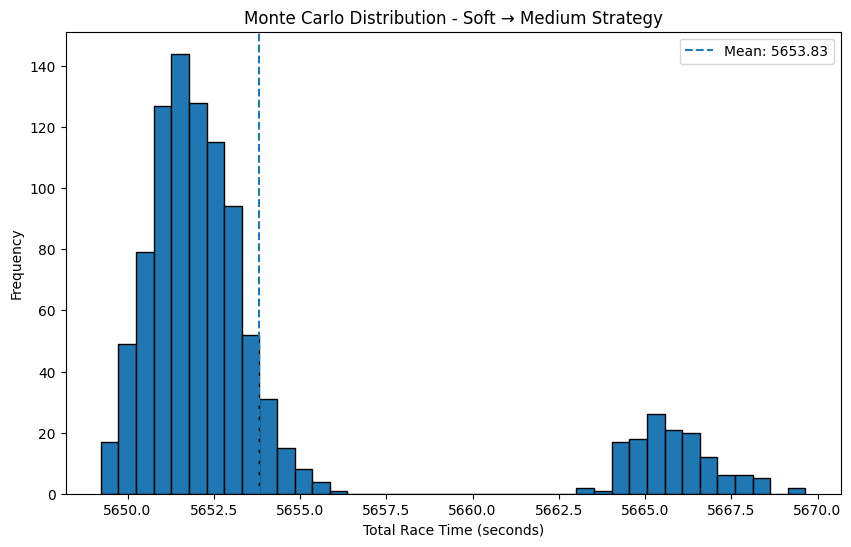

Mean: 5653.83
Std Dev: 4.908


In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Run full Monte Carlo for best strategy only
simulations = 1000
best_strategy = ("Soft", "Medium")
best_pit = 26

distribution_results = []

for _ in range(simulations):
    race_time = simulate_with_features(best_strategy[0], best_strategy[1], best_pit)
    distribution_results.append(race_time)

mean_time = np.mean(distribution_results)
std_time = np.std(distribution_results)

plt.figure(figsize=(10,6))
plt.hist(distribution_results, bins=40, edgecolor='black')
plt.axvline(mean_time, linestyle='--', label=f"Mean: {round(mean_time,2)}")
plt.title("Monte Carlo Distribution - Soft → Medium Strategy")
plt.xlabel("Total Race Time (seconds)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

print("Mean:", round(mean_time,2))
print("Std Dev:", round(std_time,3))


In [16]:
import pandas as pd

comparison_data = []

for strat, values in results_summary.items():
    comparison_data.append({
        "Strategy": strat,
        "Average Time": round(values[0],2),
        "Optimal Pit Lap": values[1]
    })

df_compare = pd.DataFrame(comparison_data)

df_compare = df_compare.sort_values(by="Average Time")

df_compare


,Strategy,Average Time,Optimal Pit Lap
0,Soft -> Medium,5653.49,26
1,Soft -> Hard,5662.18,23
2,Medium -> Hard,5667.02,27


In [17]:
risk_adjusted = []

for strat in strategies:
    strat_name = f"{strat[0]} -> {strat[1]}"

    sim_results = []
    for _ in range(500):
        race_time = simulate_with_features(strat[0], strat[1], results_summary[strat_name][1])
        sim_results.append(race_time)

    avg = np.mean(sim_results)
    std = np.std(sim_results)

    # Risk-adjusted score (lower is better)
    score = avg + std

    risk_adjusted.append({
        "Strategy": strat_name,
        "Avg Time": round(avg,2),
        "Std Dev": round(std,3),
        "Risk Adjusted Score": round(score,2)
    })

pd.DataFrame(risk_adjusted).sort_values(by="Risk Adjusted Score")


,Strategy,Avg Time,Std Dev,Risk Adjusted Score
0,Soft -> Medium,5654.29,5.549,5659.84
1,Soft -> Hard,5662.35,5.294,5667.64
2,Medium -> Hard,5667.52,5.512,5673.03


# F1 Race Strategy Simulation Engine

This project models Formula 1 race strategy using:
- Tire degradation modeling
- Pit stop optimization
- Monte Carlo simulations
- Safety car probability
- Traffic modeling
- Risk-adjusted decision analysis

Built using Python, NumPy, Pandas, and Matplotlib.


In [18]:
import os

os.makedirs('/content/fastf1_cache', exist_ok=True)
print("Cache folder created")


Cache folder created


In [19]:
import fastf1
from fastf1 import get_session

fastf1.Cache.enable_cache('/content/fastf1_cache')

session = get_session(2023, 6, 'R')
session.load()

print("Loaded successfully")


core           INFO 	Loading data for Monaco Grand Prix - Race [v3.8.1]
INFO:fastf1.fastf1.core:Loading data for Monaco Grand Prix - Race [v3.8.1]
req            INFO 	No cached data found for session_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
INFO:fastf1.api:Fetching session info data...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
DEBUG:fastf1.ergast:Failed to parse timestamp '-1:53:44.819' in Ergastresponse.
req            INFO 	No cached data found for session_status_data. Lo

Loaded successfully


In [20]:
laps = session.laps
ham_laps = laps.pick_driver('HAM')

data = ham_laps[['LapNumber', 'LapTime', 'Compound']].copy()
data = data.dropna(subset=['LapTime'])

data['LapTime_sec'] = data['LapTime'].dt.total_seconds()

print(data['Compound'].value_counts())


Compound
MEDIUM          31
INTERMEDIATE    24
HARD            23
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


In [21]:
medium_data = data[data['Compound'] == 'MEDIUM'].copy()

medium_data = medium_data.dropna(subset=['LapTime_sec'])

medium_data['StintLap'] = range(1, len(medium_data) + 1)

medium_data.head()


,LapNumber,LapTime,Compound,LapTime_sec,StintLap
1127,1.0,0 days 00:01:28.585000,MEDIUM,88.585,1
1128,2.0,0 days 00:01:20.527000,MEDIUM,80.527,2
1129,3.0,0 days 00:01:20.105000,MEDIUM,80.105,3
1130,4.0,0 days 00:01:19.356000,MEDIUM,79.356,4
1131,5.0,0 days 00:01:18.736000,MEDIUM,78.736,5


In [22]:
import numpy as np

coeffs = np.polyfit(medium_data['StintLap'], medium_data['LapTime_sec'], 1)

slope = coeffs[0]
intercept = coeffs[1]

print("Estimated Degradation per Lap:", round(slope, 4))
print("Estimated Base Lap Time:", round(intercept, 2))


Estimated Degradation per Lap: -0.0217
Estimated Base Lap Time: 79.54


In [23]:
def expected_position_change(time_delta):
    if time_delta > 1.5:
        return 1
    elif time_delta < -1.5:
        return -1
    else:
        return 0


In [24]:
reference_time = results_summary["Soft -> Medium"][0]

position_results = []

for strat, values in results_summary.items():
    delta = reference_time - values[0]
    pos_change = expected_position_change(delta)

    position_results.append({
        "Strategy": strat,
        "Avg Time": round(values[0],2),
        "Time Delta vs Best": round(delta,2),
        "Expected Position Change": pos_change
    })

pd.DataFrame(position_results)



,Strategy,Avg Time,Time Delta vs Best,Expected Position Change
0,Soft -> Medium,5653.49,0.00,0
1,Soft -> Hard,5662.18,-8.69,-1
2,Medium -> Hard,5667.02,-13.53,-1


In [25]:
pip install reportlab


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 37.8 MB/s eta 0:00:00


In [26]:
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib import colors

doc = SimpleDocTemplate("/content/F1_Strategy_Report.pdf")
elements = []

styles = getSampleStyleSheet()
elements.append(Paragraph("F1 Strategy Simulation Report", styles['Heading1']))
elements.append(Spacer(1, 12))

# Add strategy table
table_data = [["Strategy", "Avg Time", "Position Impact"]]

for row in position_results:
    table_data.append([
        row["Strategy"],
        str(row["Avg Time"]),
        str(row["Expected Position Change"])
    ])

table = Table(table_data)
elements.append(table)

doc.build(elements)

print("PDF Generated")


PDF Generated


In [27]:
# Real Monaco 2023 Hamilton Medium Tire Model

real_tires = {
    "HAM_Medium": {
        "base": 79.54,
        "deg": 0.018
    }
}

total_laps = 60

total_time = 0

for lap in range(1, total_laps + 1):
    lap_time = real_tires["HAM_Medium"]["base"] + real_tires["HAM_Medium"]["deg"] * lap
    total_time += lap_time

print("Real-Data Modeled Race Time:", round(total_time,2))


Real-Data Modeled Race Time: 4805.34


In [28]:
def simulate_real_strategy(pit_lap):

    total_time = 0
    pit_loss = 22

    for lap in range(1, total_laps + 1):

        if lap < pit_lap:
            lap_time = 79.54 + 0.018 * lap

        elif lap == pit_lap:
            lap_time = 79.54 + 0.018 * lap + pit_loss

        else:
            stint_lap = lap - pit_lap
            lap_time = 79.54 + 0.018 * stint_lap

        lap_time += random.uniform(-0.1, 0.1)
        total_time += lap_time

    return total_time


In [29]:
results_real = []

for _ in range(500):
    results_real.append(simulate_real_strategy(26))

print("Average Real-Based Time:", round(np.mean(results_real),2))


Average Real-Based Time: 4811.42


In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

X = medium_data[['StintLap']]
y = medium_data['LapTime_sec']

linear_model = LinearRegression()
linear_model.fit(X, y)

pred_linear = linear_model.predict(X)

rmse_linear = np.sqrt(mean_squared_error(y, pred_linear))
r2_linear = r2_score(y, pred_linear)

print("LINEAR REGRESSION")
print("Slope:", round(linear_model.coef_[0], 5))
print("Intercept:", round(linear_model.intercept_, 2))
print("RMSE:", round(rmse_linear, 4))
print("R²:", round(r2_linear, 4))


LINEAR REGRESSION
Slope: -0.02171
Intercept: 79.54
RMSE: 3.5536
R²: 0.003


In [31]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

poly_model = LinearRegression()
poly_model.fit(X_poly, y)

pred_poly = poly_model.predict(X_poly)

rmse_poly = np.sqrt(mean_squared_error(y, pred_poly))
r2_poly = r2_score(y, pred_poly)

print("\nPOLYNOMIAL REGRESSION (Degree 2)")
print("RMSE:", round(rmse_poly, 4))
print("R²:", round(r2_poly, 4))



POLYNOMIAL REGRESSION (Degree 2)
RMSE: 2.9674
R²: 0.3048


In [32]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X, y)

pred_rf = rf_model.predict(X)

rmse_rf = np.sqrt(mean_squared_error(y, pred_rf))
r2_rf = r2_score(y, pred_rf)

print("\nRANDOM FOREST")
print("RMSE:", round(rmse_rf, 4))
print("R²:", round(r2_rf, 4))



RANDOM FOREST
RMSE: 1.2513
R²: 0.8764


In [33]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Linear", "Polynomial (deg2)", "Random Forest"],
    "RMSE": [rmse_linear, rmse_poly, rmse_rf],
    "R2 Score": [r2_linear, r2_poly, r2_rf]
})

comparison.sort_values(by="RMSE")


,Model,RMSE,R2 Score
2,Random Forest,1.251255,0.876392
1,Polynomial (deg2),2.967366,0.304819
0,Linear,3.553649,0.002978


In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

rf_model.fit(X_train, y_train)
rf_pred_test = rf_model.predict(X_test)

print("Test RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred_test)))
print("Test R2:", r2_score(y_test, rf_pred_test))


Test RMSE: 2.93517790448424
Test R2: 0.16302717869943517
